In [ ]:
#%% imports and file settings
import os, sys
import numpy as np
import pandas as pd
from psm_utils.io import read_file
from upsetplot import UpSet, plot
import matplotlib.pyplot as plt


# Add the parent directory to the Python path
parent_dir = os.getcwd()
sys.path.insert(0, parent_dir)

# Now import the modules from the src directory
import src.percolator_file_functions as pff
import src.fdr_functions as fdrf

###
### parameters
###
# basepath: the path for same datasets, inside could be several databases (subforlders)
basepath = "/mnt/data/pipeline-of-identifications/publication/PXD028735-LFQ_Orbitrap/"

# databases: list of databases, basically subpaths
databases = ["sprot", "proteome", "prohap"]

# searchengines can be defined (subfolders under DBs)
searchengines = ["comet", "maxquant", "msamanda", "msfragger", "msgfplus", "sage", "xtandem"]

# idlevel
idlevel = "peptidoform" # peptidoform, psms

# temporary, until all is implemented
upset_db = "sprot"
upset_postprocess = "ms2rescore" # tda, percolator, ms2rescore
upset_idlevel = idlevel # peptidoform, psms

# TODO: create plots from all postprocess_levels, DBs and use intervals of replicates
# TODO: create upset-plots from all postprocess_levels and DBs and use mean/stddev of replicates


### -----------------------------------------------------
### below here, no further settings should be necessary

se_to_basescore = {
    "comet": "neg_ln_comet_expectation_value",
    "maxquant": "maxquant_Score",
    "msamanda": "amanda_score",
    "msfragger": "neg_ln_msfragger_expect",
    "msgfplus": "ln_msgf_specevalue",
    "sage": "sage_discriminant_score",
    "xtandem": "neg_ln_xtandem_expect"
}

postprocess_levels = ["tda", "percolator", "ms2rescore", "oktoberfest"]

In [2]:
# look for files in the folders
initial_search_pin_suffix = "psm_utils.pin"
percolator_out_suffix = "psm_utils.pout"
ms2rescore_percolator_pin_suffix = "ms2rescore.corrected.pin"
ms2rescore_percolator_out_suffix = "ms2rescore.corrected.pout"
oktoberfest_percolator_pin_suffix = "features.oktoberfest.pin"
oktoberfest_percolator_out_suffix = "features.oktoberfest.pout"

files = {}
for database in databases:
    files[database] = {}
    for searchengine in searchengines:
        path = f"{basepath}/{database}/{searchengine}/"

        lst = os.listdir(path)
        lst.sort()

        files[database][searchengine] = {}
        files[database][searchengine]["initial_search_pin"]                 = [f"{path}/{f}" for f in lst if f.endswith(initial_search_pin_suffix)]
        files[database][searchengine]["percolator_out"]                     = [f"{path}/{f}" for f in lst if f.endswith(percolator_out_suffix)]
        files[database][searchengine]["ms2rescore_percolator_pin"]          = [f"{path}/{f}" for f in lst if f.endswith(ms2rescore_percolator_pin_suffix)]
        files[database][searchengine]["ms2rescore_percolator_out"]          = [f"{path}/{f}" for f in lst if f.endswith(ms2rescore_percolator_out_suffix)]
        files[database][searchengine]["oktoberfest_percolator_pin"]          = [f"{path}/{f}" for f in lst if f.endswith(oktoberfest_percolator_pin_suffix)]
        files[database][searchengine]["oktoberfest_percolator_out"]          = [f"{path}/{f}" for f in lst if f.endswith(oktoberfest_percolator_out_suffix)]

# infer number of runs / raw files from first db / first searchengine
nr_runs = len(files[databases[0]][searchengines[0]]['initial_search_pin'])

In [5]:
# read in the results / files
filter_cutoff = 0.01

results = {}
for database in databases:
    print(f"reading in results of {database}")
    results[database] = {}
    for searchengine in searchengines:
        print(f"\treading in searchengine {searchengine}")
        results[database][searchengine] = {
            "tda": [],
            "percolator": [],
            "ms2rescore": [],
            "oktoberfest": []
        }

        for rep in range(nr_runs):
            print(f"\t\treading in run {rep}")
            # read in the initial search results (from PIN)
            se_score = se_to_basescore[searchengine]
            pin_file = files[database][searchengine]["initial_search_pin"][rep]
            pin_df = pff.parse_percolator_pin(pin_file)
            pin_df[se_score] = pd.to_numeric(pin_df[se_score])
            # calculate the FDR
            pin_df = fdrf.calculate_fdr(pin_df, se_score)
            results[database][searchengine]["tda"].append(pin_df[pin_df['q-value'] <= filter_cutoff])

            # read in the percolator results
            pout_file = files[database][searchengine]["percolator_out"][rep]
            pout_df = pff.read_enriched_pout_with_pin_data(pout_file, pin_file)
            results[database][searchengine]["percolator"].append(pout_df[pout_df['q-value'] <= filter_cutoff])

            # read in the percolator after MS2Rescore results
            ms2rescore_pin_file = files[database][searchengine]["ms2rescore_percolator_pin"][rep]
            ms2rescore_pout_file = files[database][searchengine]["ms2rescore_percolator_out"][rep]
            ms2rescore_pout_df = pff.read_enriched_pout_with_pin_data(ms2rescore_pout_file, ms2rescore_pin_file)
            results[database][searchengine]["ms2rescore"].append(ms2rescore_pout_df[ms2rescore_pout_df['q-value'] <= filter_cutoff])

            # read in the percolator after Oktoberfest results
            oktoberfeste_pin_file = files[database][searchengine]["oktoberfest_percolator_pin"][rep]
            oktoberfeste_pout_file = files[database][searchengine]["oktoberfest_percolator_out"][rep]
            oktoberfest_pout_df = pff.read_enriched_pout_with_pin_data(oktoberfeste_pout_file, oktoberfeste_pin_file)
            results[database][searchengine]["oktoberfest"].append(oktoberfest_pout_df[oktoberfest_pout_df['q-value'] <= filter_cutoff])


# 28m 48.8s

reading in results of sprot
	reading in searchengine comet
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine maxquant
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine msamanda
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine msfragger
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine msgfplus
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine sage
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine xtandem
		reading in run 0
		reading in run 1
		reading in run 2
reading in results of proteome
	reading in searchengine comet
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine maxquant
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine msamanda
		reading in run 0
		reading in run 1
		reading in run 2
	reading in searchengine msfragger
		read

In [6]:
#### textout of results
idlevel = "psms" # peptidoform, psms

filenames = [os.path.basename(f).split('.', 1)[0] for f in files[databases[0]][searchengines[0]]['initial_search_pin']]

# Create a MultiIndex DataFrame to store the results
index = pd.MultiIndex.from_product([postprocess_levels, searchengines], names=["postprocess_level", "searchengine"])

df_columns = []
for db in databases:
    df_columns.append(db)
    df_columns.append(f"{db} stdev")
    for name in filenames:
        df_columns.append(name)
    

results_df = pd.DataFrame(index=index, columns=df_columns)

for postprocess_level in postprocess_levels:
    for se in searchengines:
        for db in databases:
            rep_results = []
            for rep in range(nr_runs):
                df_rep = results[db][se][postprocess_level][rep]
                filtered = df_rep[df_rep['q-value'] <= 0.01]

                peprowname = "peptide"
                if (postprocess_level == "tda"):
                    peprowname = "Peptide"
                    filtered = filtered[filtered["is_decoy"] == False]

                if (idlevel == "psms"):
                    rep_results.append(len(filtered))
                elif (idlevel == "peptidoform"):
                    count_set = set()
                    for _, row in filtered.iterrows():
                        # here it is selected whether to use PSMs or peptidoforms (or maybe even peptides??)
                        count_set.add(f"{row[peprowname].replace("I", "J").replace("L", "J").replace("UNJMOD", "UNIMOD")}")
                    rep_results.append(len(count_set))
                
                results_df.loc[(postprocess_level, se), filenames[rep]] = rep_results[rep]

            results_df.loc[(postprocess_level, se), db] = np.mean(rep_results)
            results_df.loc[(postprocess_level, se), f"{db} stdev"] = np.std(rep_results)

print(results_df)

                                       sprot  sprot stdev  \
postprocess_level searchengine                              
tda               comet              48841.0  1116.172328   
                  maxquant           28358.0   749.114588   
                  msamanda      47092.333333  1013.180581   
                  msfragger     55900.666667  1195.352482   
                  msgfplus      60761.666667  1953.016186   
                  sage          58756.333333  1477.908958   
                  xtandem            39617.0  1034.761164   
percolator        comet         54859.666667  1151.730389   
                  maxquant      35507.666667  1012.038976   
                  msamanda           50245.0  1145.012081   
                  msfragger          58467.0  1217.145294   
                  msgfplus      66576.333333   1754.74259   
                  sage               60183.0  1230.982534   
                  xtandem            50626.0  1093.764448   
ms2rescore        comet 

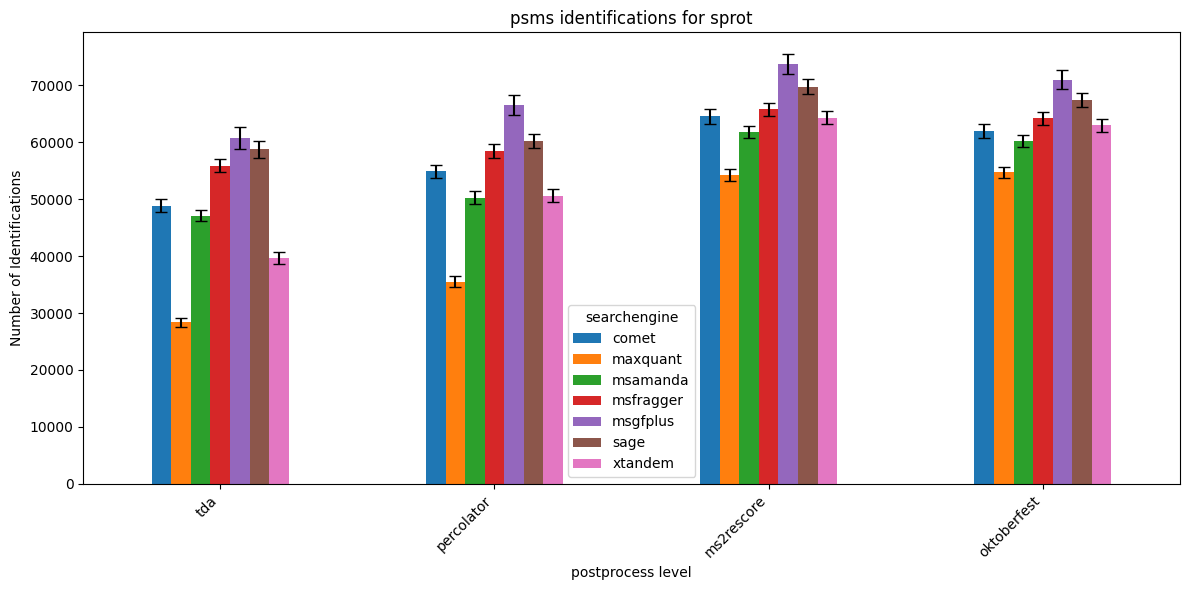

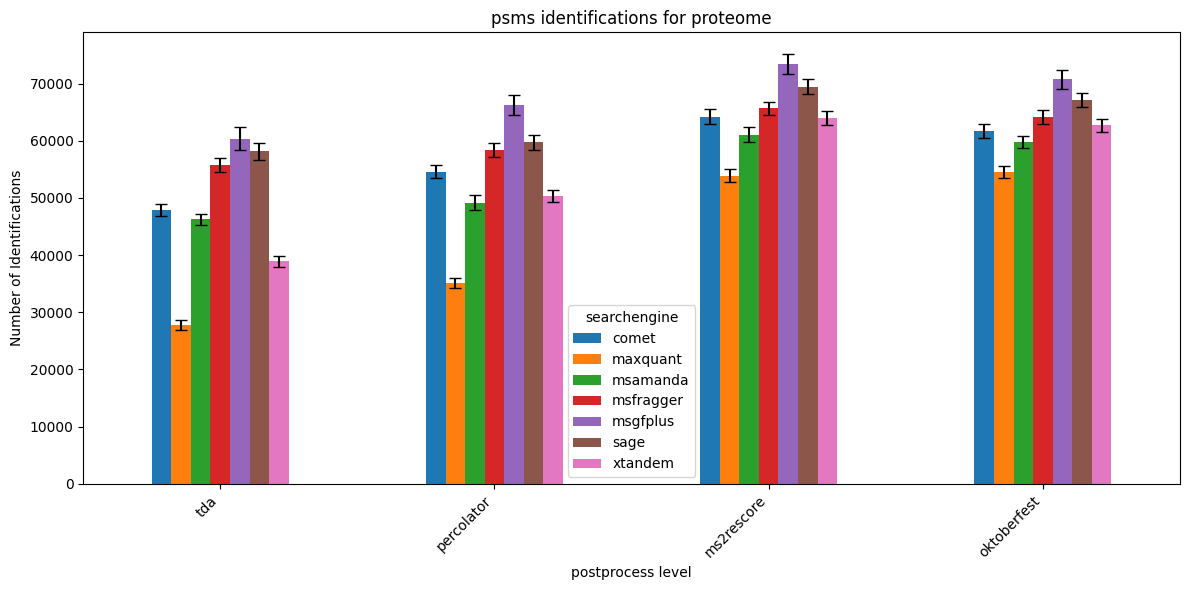

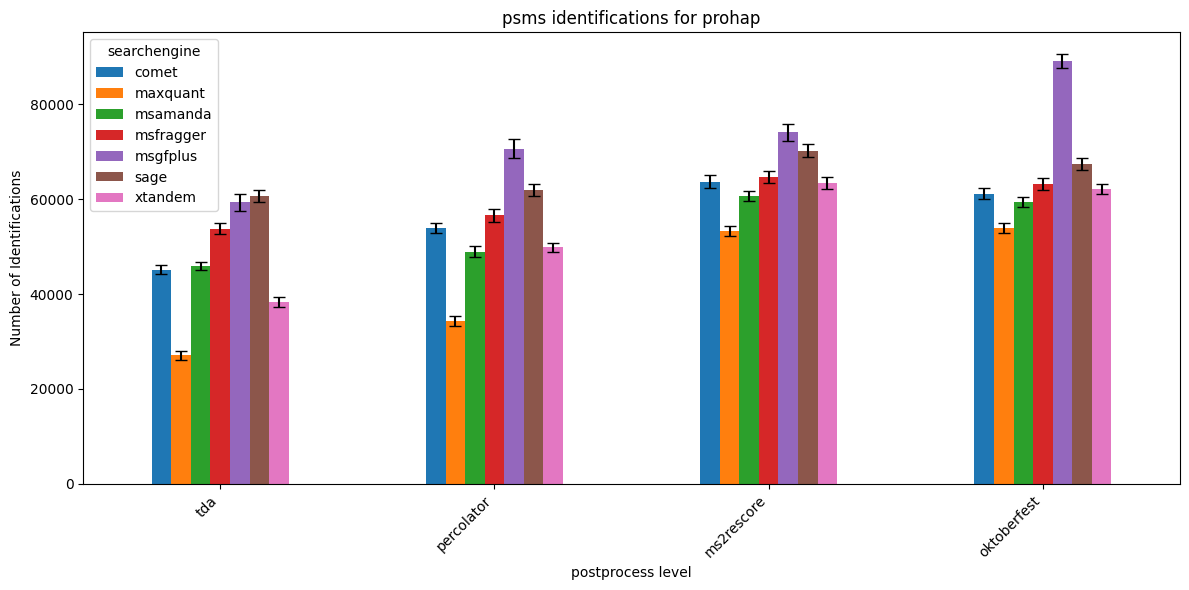

In [7]:
# Plot bar charts for each database from results_df

for db in databases:
    means = results_df[db].astype(float)
    stds = results_df[f"{db} stdev"].astype(float)

    # Unstack to get postprocess_level as columns, searchengine as index
    means_unstacked = means.unstack(level=-1, sort=False)
    stds_unstacked = stds.unstack(level=-1, sort=False)

    ax = means_unstacked.plot.bar(yerr=stds_unstacked, figsize=(12, 6), capsize=4)
    ax.set_title(f"{idlevel} identifications for {db}")
    ax.set_ylabel("Number of Identifications")
    ax.set_xlabel("postprocess level")
    ax.set_xticklabels(means_unstacked.index, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


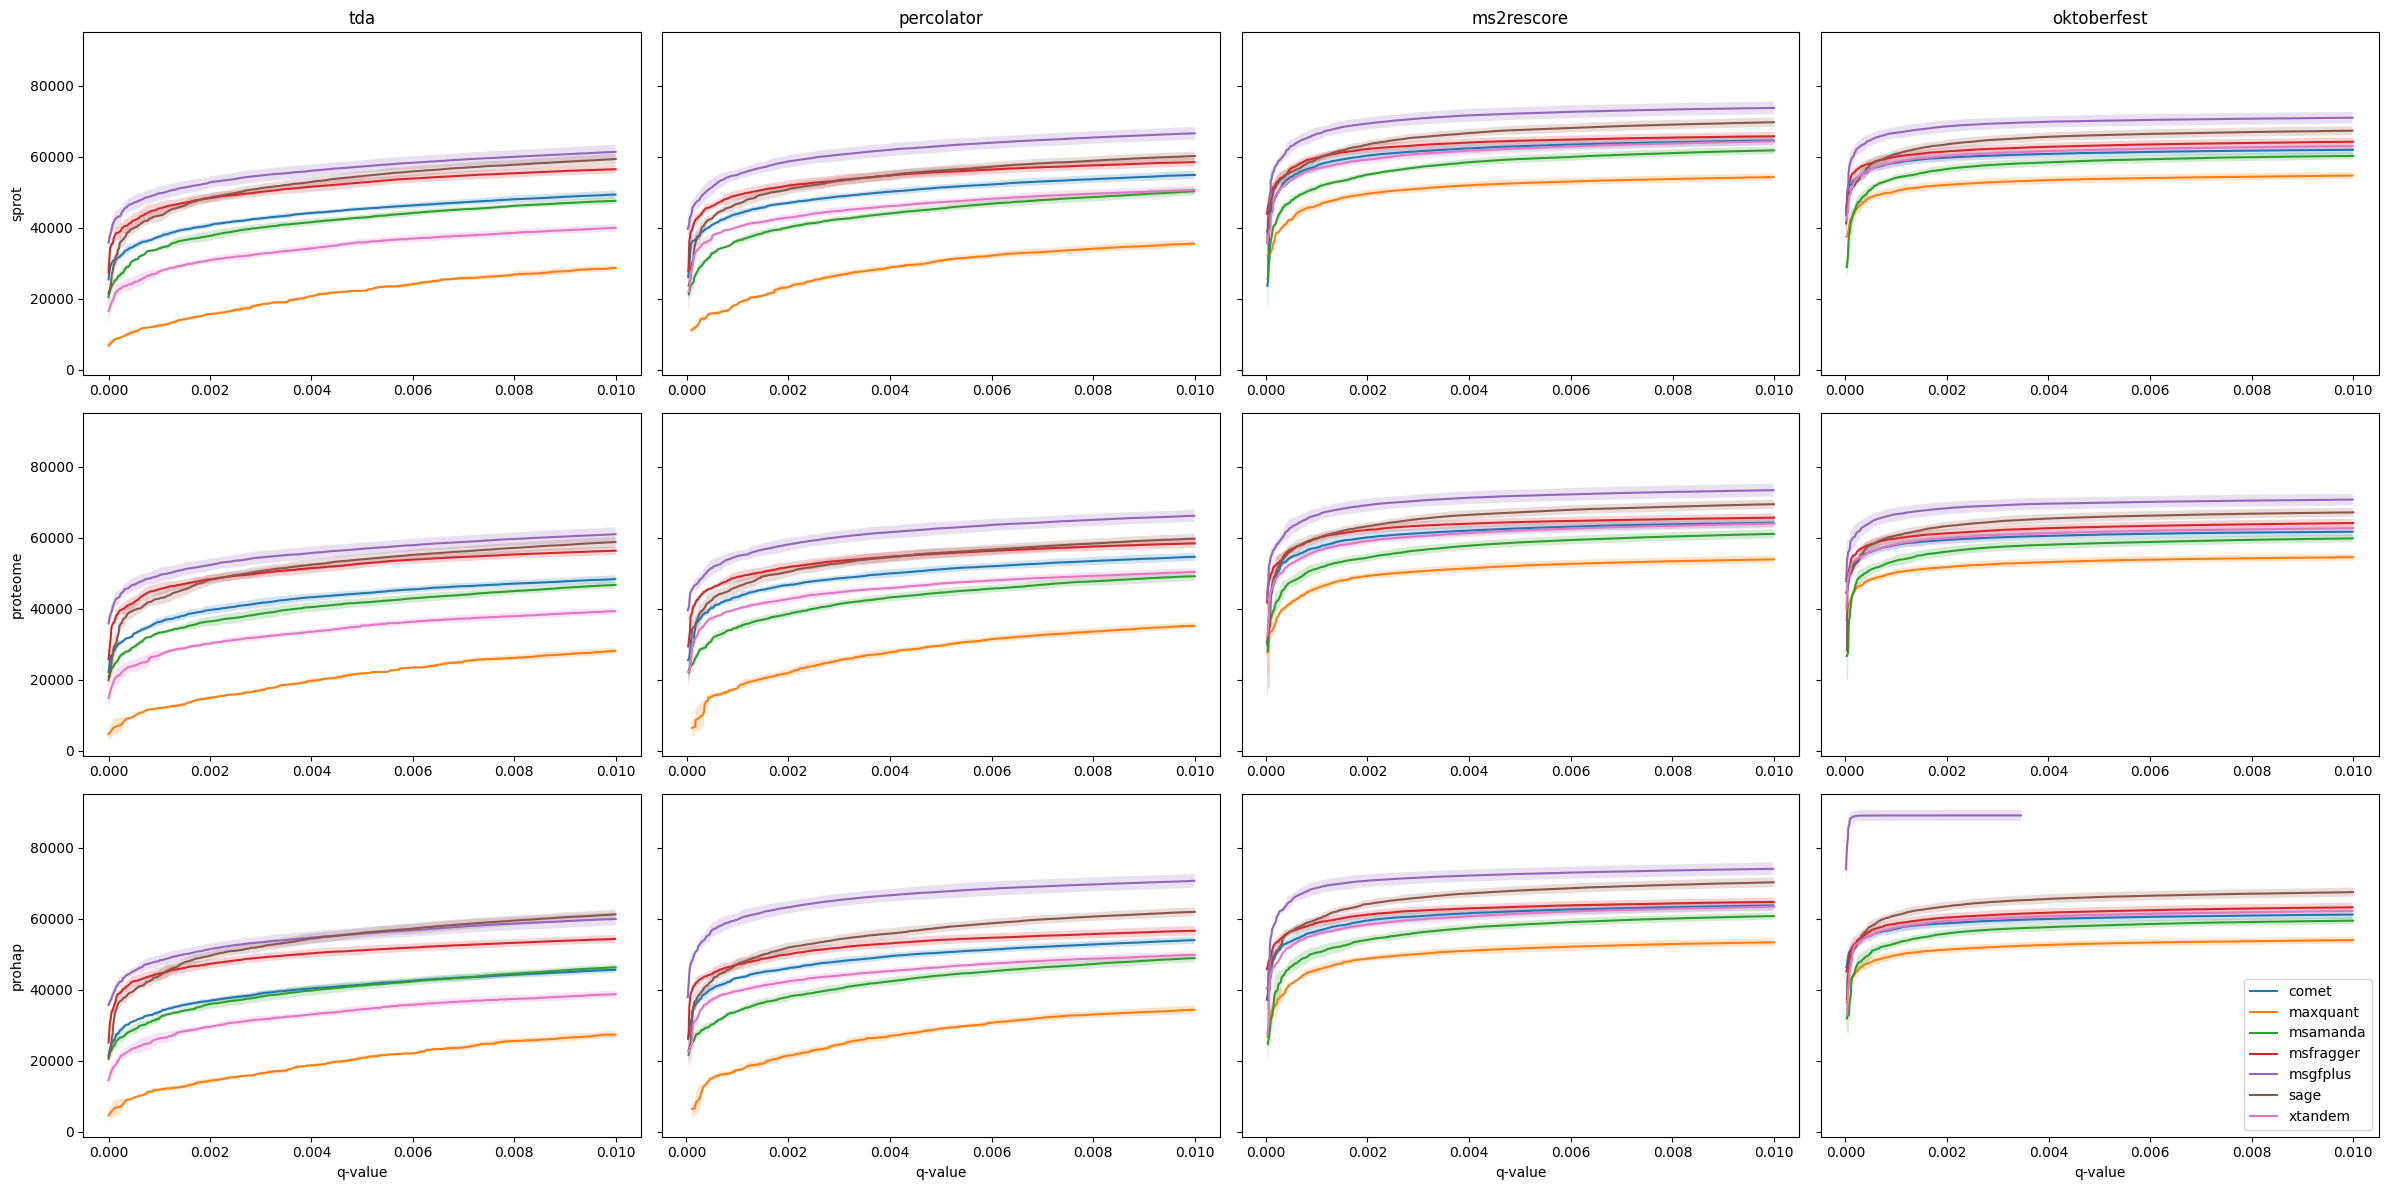

In [8]:
# Plot pseudo ROC curves

# Create a matrix of PSM plots: rows=databases, cols=postprocess_levels
fig, axes = plt.subplots(len(databases), len(postprocess_levels), figsize=(6*len(postprocess_levels), 4*len(databases)), sharey=True)

for i_db, db in enumerate(databases):
    for j_pp, postprocess_level in enumerate(postprocess_levels):
        if len(databases) == 1:
            ax = axes[j_pp]
        else:
            ax = axes[i_db, j_pp]
        for se in searchengines:
            # Collect cumulative curves for all replicates
            cumulative_curves = []
            qvalue_grids = []

            for rep in range(nr_runs):
                df_rep = results[db][se][postprocess_level][rep]
                filtered_df_rep = df_rep[df_rep["q-value"] <= 0.01]
                if filtered_df_rep.empty:
                    continue
                df_counted_rep = filtered_df_rep.sort_values("q-value").groupby(by=["q-value"]).count()
                df_counted_rep['cumulative'] = df_counted_rep.iloc[:, 0].cumsum()
                df_counted_rep['cumulative_norm'] = df_counted_rep['cumulative'] / df_counted_rep['cumulative'].max()
                qvalue_grids.append(df_counted_rep.index.values)
                cumulative_curves.append(df_counted_rep['cumulative'].values)

            # Interpolate all curves to a common q-value grid for averaging
            if cumulative_curves:
                # Define a common grid (union of all q-values)
                q_grid = np.unique(np.concatenate(qvalue_grids))
                interpolated_curves = []
                for qv, cum in zip(qvalue_grids, cumulative_curves):
                    interp = np.interp(q_grid, qv, cum)
                    interpolated_curves.append(interp)
                interpolated_curves = np.array(interpolated_curves)
                mean_curve = np.mean(interpolated_curves, axis=0)
                std_curve = np.std(interpolated_curves, axis=0)
                ax.plot(q_grid, mean_curve, label=f"{se}")
                ax.fill_between(q_grid, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)
        
        if i_db == 0:
            ax.set_title(postprocess_level)
        if j_pp == 0:
            ax.set_ylabel(db)
        if i_db == len(databases) - 1:
            ax.set_xlabel("q-value")
        if i_db == len(databases) - 1 and j_pp == len(postprocess_levels) - 1:
            ax.legend()
plt.tight_layout()

In [19]:
# data for upset plot
upset_db = "proteome"
upset_postprocess = "oktoberfest" # "tda", "percolator", "ms2rescore", "oktoberfest"
upset_idlevel = "peptidoform" # "peptidoform"

db = upset_db
postprocess = upset_postprocess

proteoform_sets = [{}]*nr_runs

all_elems = [set()]*nr_runs
for searchengine, postprocessed_data in results[db].items():
    data = postprocessed_data[postprocess]
    for i in range(nr_runs):
        # filter by q-value and set the proteoform columns
        filtered = data[i][data[i]["q-value"] <= 0.01]
        peprowname = "peptide"
        if (postprocess == "tda"):
            peprowname = "Peptide"
            filtered = filtered[filtered["is_decoy"] == False]

        proteoform_sets[i][searchengine] = set()
        for _, row in filtered.iterrows():
            # here it is selected whether to use PSMs or peptidoforms (or maybe even peptides??)
            if (upset_idlevel == "psms"):
                proteoform_sets[i][searchengine].add(f"{row['ScanNr']}:{row[peprowname].replace("I", "J").replace("L", "J").replace("UNJMOD", "UNIMOD")}")
            elif (upset_idlevel == "peptidoform"):
                proteoform_sets[i][searchengine].add(f"{row[peprowname].replace("I", "J").replace("L", "J").replace("UNJMOD", "UNIMOD")}")
        all_elems[i] = all_elems[i].union(proteoform_sets[i][searchengine])

df = []
for elems in all_elems:
    df.append(pd.DataFrame(None, list(elems)))

for i in range(nr_runs):
    for name, dataset in proteoform_sets[i].items():
        df[i][name] = df[i].index.map(lambda x: x in dataset)

# df[i] holds for run i whether a proteoform was found with the respective search engine

## TODO: use the mean / stddev of the replicates
upsetdata = df[0]

In [20]:
%%capture
%load_ext rpy2.ipython

%R -i upsetdata -i searchengines -i upset_postprocess -i upset_db


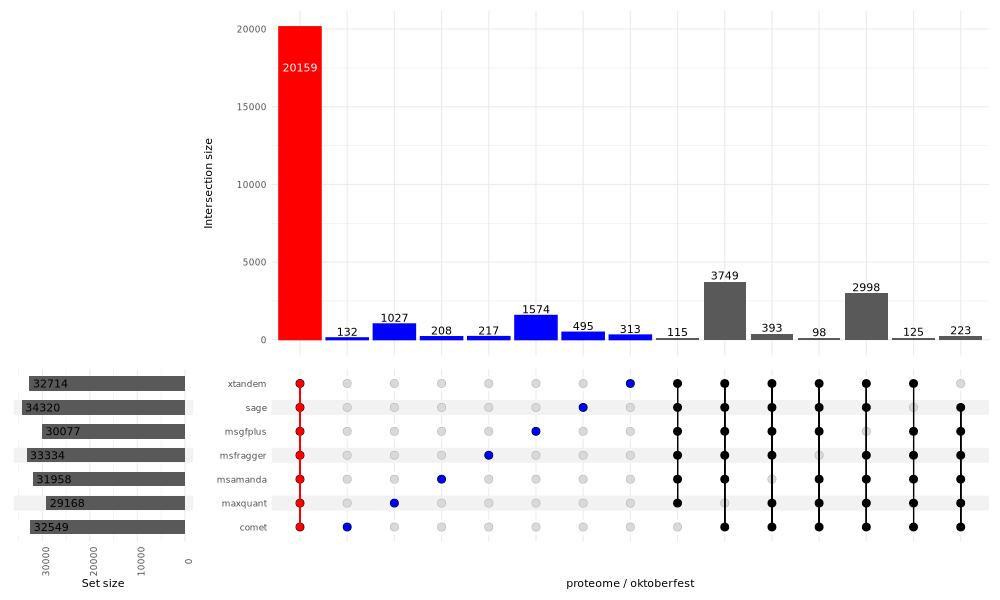

In [21]:
%%R -w 1000 -h 600

library(ggplot2)
library(ComplexUpset)

upset(upsetdata, searchengines,
    name=paste(upset_db, upset_postprocess, sep=" / "),
    width_ratio=0.2,
    intersections=list(
        c('comet', 'maxquant', 'msamanda', 'msfragger', 'msgfplus', 'sage', 'xtandem'),
        'comet',
        'maxquant',
        'msamanda',
        'msfragger',
        'msgfplus',
        'sage',
        'xtandem',
        c(         'maxquant', 'msamanda', 'msfragger', 'msgfplus', 'sage', 'xtandem'),
        c('comet'            , 'msamanda', 'msfragger', 'msgfplus', 'sage', 'xtandem'),
        c('comet', 'maxquant'            , 'msfragger', 'msgfplus', 'sage', 'xtandem'),
        c('comet', 'maxquant', 'msamanda'             , 'msgfplus', 'sage', 'xtandem'),
        c('comet', 'maxquant', 'msamanda', 'msfragger'            , 'sage', 'xtandem'),
        c('comet', 'maxquant', 'msamanda', 'msfragger', 'msgfplus'        , 'xtandem'),
        c('comet', 'maxquant', 'msamanda', 'msfragger', 'msgfplus', 'sage')
    ),
    sort_sets=F, sort_intersections=F,
    queries=list(
        upset_query(
            intersect=c('comet', 'maxquant', 'msamanda', 'msfragger', 'msgfplus', 'sage', 'xtandem'),
            color='red', fill='red',
            only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('comet'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('maxquant'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('msamanda'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('msfragger'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('msgfplus'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('sage'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        ),
        upset_query(
            intersect=c('xtandem'), color='blue', fill='blue', only_components=c('intersections_matrix', 'Intersection size')
        )
    ),
    set_sizes=(
        upset_set_size()
        + geom_text(aes(label=..count..), hjust=-0.1, stat='count')
        #+ expand_limits(y=70000)
        + theme(axis.text.x=element_text(angle=90))
    )
)

In [ ]:

results["proteome"]["msamanda"]["ms2rescore"][rep]


,ScanNr,score,q-value,posterior_error_prob,peptide,proteinIds
PSMId,,,,,,
111563,131926,3.227530,0.000034,0.000024,.VIHDNFGIVEGLMTTVHAITATQK.,sp|P04406\tsp|P04406-2\ttr|E7EUT5
96146,114346,3.188480,0.000034,0.000024,.VIHDNFGIVEGLM[UNIMOD:Oxidation]TTVHAITATQK.,sp|P04406\tsp|P04406-2\ttr|E7EUT5
83707,100440,3.041810,0.000034,0.000024,.GSGDPSSSSSSGNPLVYLDVDANGKPLGR.,tr|R4GN99\tsp|P30405\tsp|P30405-2
111086,131364,3.040580,0.000034,0.000024,.VIHDNFGIVEGLMTTVHAITATQK.,sp|P04406\tsp|P04406-2\ttr|E7EUT5
102185,121167,2.993830,0.000034,0.000024,.ALANVNIGSLIC[UNIMOD:Carbamidomethyl]NVGAGGPAP...,sp|P05386
...,...,...,...,...,...,...
111591,131960,0.000042,0.009943,0.186713,.SQGPALTASQSVHEQPTK.,sp|Q9UKE5\tsp|Q9UKE5-8\tsp|Q9UKE5-7\tsp|Q9UKE5...
100180,118887,0.000000,0.009943,0.186792,.QIQELVEAIVLPMNHK.,sp|P17980\ttr|E9PN50\ttr|E9PMD8\ttr|E9PM69\tsp...
69604,84879,0.000000,0.009943,0.186871,.LDDLFLK.,tr|A0A804HIG4\ttr|A0A804HLG8\ttr|A0A804HL40\tt...


PSMId
LFQ_Orbitrap_DDA_Human_01-100440-GSGDPSSSSSSGNPLVYLDVDANGKPLGR-3                                                     .GSGDPSSSSSSGNPLVYLDVDANGKPLGR.
LFQ_Orbitrap_DDA_Human_01-114346-VIHDNFGIVEGLM[UNIMOD:35]TTVHAITATQK-3                                  .VIHDNFGIVEGLM[UNIMOD:Oxidation]TTVHAITATQK.
LFQ_Orbitrap_DDA_Human_01-126795-AGLPC[UNIMOD:4]QDLEFVQFHPTGIYGAGC[UNIMOD:4]LITEGC[UNIMOD:4]R-3    .AGLPC[UNIMOD:Carbamidomethyl]QDLEFVQFHPTGIYGA...
LFQ_Orbitrap_DDA_Human_01-125311-TTIPEEEEEEEEAAGVVVEEELFHQQGTPR-3                                                   .TTIPEEEEEEEEAAGVVVEEELFHQQGTPR.
LFQ_Orbitrap_DDA_Human_01-131364-VIHDNFGIVEGLMTTVHAITATQK-3                                                               .VIHDNFGIVEGLMTTVHAITATQK.
                                                                                                                         ...                        
LFQ_Orbitrap_DDA_Human_01-5177-SIQHHLR-2                                                            

In [1]:
from upsetplot import UpSet, plot, from_contents
from functools import reduce

#############
# same engine, differing DBs
searchengine = "msgfplus"
rep = 0


# TODO: put this into the reading in of data...
OKTOBERFEST_MODIFICATION_REPLACEMENTS = [
    ("[UNIMOD:Carbamidomethyl]", "[UNIMOD:4]"),
    ("[UNIMOD:Oxidation]", "[UNIMOD:35]"),
]

def replace_oktoberfest_modifications(sequences):
    return sequences.apply(
        lambda x: x.strip("_")
    ).apply(
        lambda seq: reduce(
            lambda seq_x, repl: seq_x.replace(repl[1], repl[0]), # lambda to replace
            OKTOBERFEST_MODIFICATION_REPLACEMENTS, # replacements
            seq # starting with the sequences as stated in the PSMs file
        )
    )


psm_sets = {}
for db in databases:
    for postprocessing in postprocess_levels:
        if postprocessing == "oktoberfest":
            results[db][searchengine][postprocessing][rep]["peptide"] = replace_oktoberfest_modifications(results[db][searchengine][postprocessing][rep]["peptide"])

        peprowname = "peptide"
        if (postprocessing == "tda"):
            peprowname = "Peptide"
        psm_sets[f"{db}-{postprocessing}"] = set(row[peprowname].replace("I", "J").replace("L", "J").replace("UNJMOD", "UNIMOD") for _, row in results[db][searchengine][postprocessing][rep].iterrows())
    

# Build a DataFrame for UpSet plot
upset_data = from_contents(psm_sets)

# Plot the UpSet plot
plt.figure(figsize=(8, 4))
UpSet(upset_data, subset_size='count', show_counts=True, min_subset_size=100).plot()
plt.title(f"UpSet plot of peptides (replicate {rep}, searchengine: {searchengine})")
plt.show()

NameError: name 'databases' is not defined